**Problem**
- Predict whether a loan applicant will default or repay successfully.
- Real-world credit risk datasets are imbalanced (few defaults vs. many non-defaults).

**Approach**
- Synthetic dataset simulating applicant profiles (age, income, loan amount, credit score, employment).
- Preprocessing: Encoded categorical features, scaled numerical ones.
- Imbalance Handling: Used SMOTE (Synthetic Minority Oversampling Technique) to balance the dataset.

**Models:**
- Logistic Regression with class weights.
- Random Forest with class weights.

**Evaluation Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC.

**Key Insights**
- SMOTE improved recall (capturing more defaulters).
- Random Forest performed better in terms of ROC-AUC and F1 score compared to Logistic Regression.
- ROC Curve & Confusion Matrix provided better interpretability for model performance.

**Enterprise Use Case**
- Banks & fintech companies can use this pipeline to assess loan risk before approving.
- Helps reduce non-performing assets (NPAs) and credit losses.
- Can be integrated with real-time scoring engines for instant decisions.

### 1. Import Libraries

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
)

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

### 2. Create Synthetic Dataset


In [2]:
# Dataset link https://www.kaggle.com/datasets/nikhil1e9/loan-default
df = pd.read_csv('Data/Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


### 3. Preprocessing


In [3]:
# Drop LoanID since it's just an identifier
df = df.drop("LoanID", axis=1)

# Features & Target
X = df.drop("Default", axis=1)
y = df["Default"]

# Scale numerical features
scaler = StandardScaler()
num_cols = ["Age", "Income", "LoanAmount", "CreditScore", "MonthsEmployed",
            "NumCreditLines", "InterestRate", "LoanTerm", "DTIRatio"]

X[num_cols] = scaler.fit_transform(X[num_cols])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nBefore SMOTE class distribution:")
print(y_train.value_counts())





Before SMOTE class distribution:
Default
0    180555
1     23722
Name: count, dtype: int64


### 4. Handle Imbalance (SMOTE)

In [6]:
# Identify non-numeric columns (object or category types)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Encode categorical columns, if any
if len(cat_cols) > 0:
    le = LabelEncoder()
    for col in cat_cols:
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))

# Now apply SMOTE safely
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE class distribution:")
print(y_train_res.value_counts())



After SMOTE class distribution:
Default
0    180555
1    180555
Name: count, dtype: int64


### 5. Model Training


In [7]:
# Logistic Regression (no need for class_weight since SMOTE balanced the data)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

print(" Models trained successfully on SMOTE-balanced data.")


✅ Models trained successfully on SMOTE-balanced data.


### 6. Model Evaluation



🔹 Model: Logistic Regression
              precision    recall  f1-score   support

           0     0.9354    0.7087    0.8065     45139
           1     0.2207    0.6277    0.3266      5931

    accuracy                         0.6993     51070
   macro avg     0.5781    0.6682    0.5665     51070
weighted avg     0.8524    0.6993    0.7507     51070

ROC-AUC: 0.7319


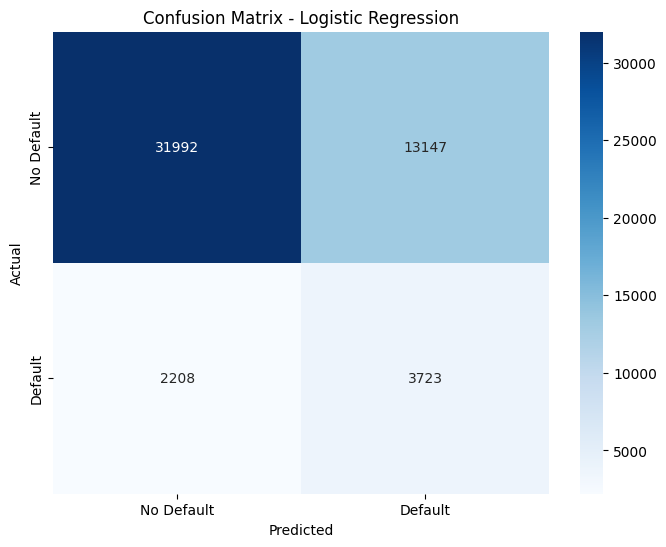


🔹 Model: Random Forest
              precision    recall  f1-score   support

           0     0.9091    0.9095    0.9093     45139
           1     0.3092    0.3082    0.3087      5931

    accuracy                         0.8397     51070
   macro avg     0.6092    0.6089    0.6090     51070
weighted avg     0.8395    0.8397    0.8396     51070

ROC-AUC: 0.7274


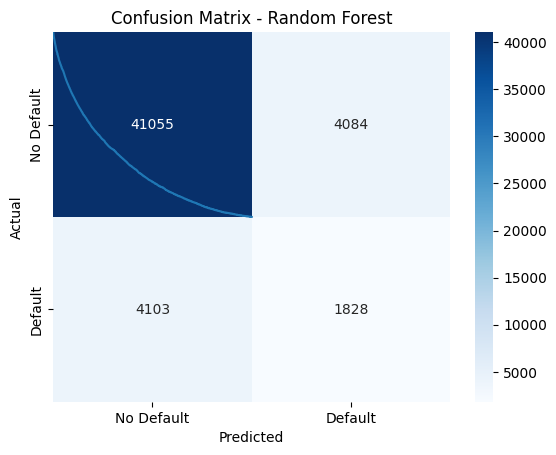

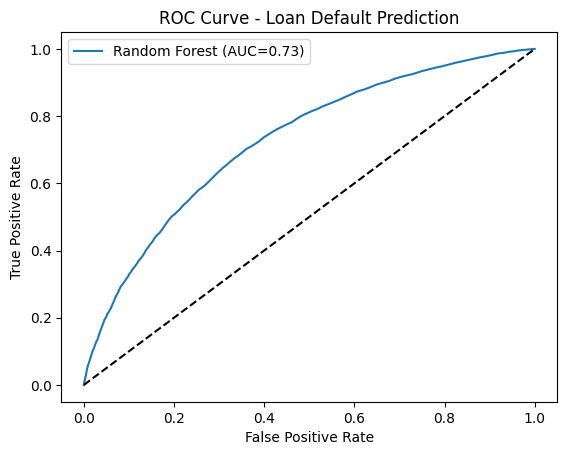

In [8]:
# Ensure categorical columns in X_test are encoded (same as train)
cat_cols = X_test.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    for col in cat_cols:
        X_test[col] = le.transform(X_test[col].astype(str))

# Evaluate both models
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    print(f"\n🔹 Model: {name}")
    print(classification_report(y_test, y_pred, digits=4))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Default", "Default"],
                yticklabels=["No Default", "Default"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.2f})")

# Combined ROC Curve
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Loan Default Prediction")
plt.legend()
plt.show()
